In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

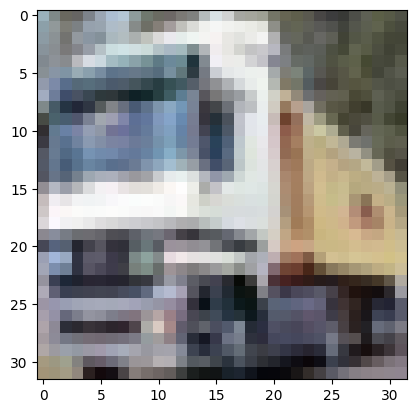

In [5]:
import matplotlib.pyplot as plt
plt.imshow(train_images[1])

In [8]:
train_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [9]:
train_filter = (train_labels == 3) | (train_labels == 5)
test_filter  = (test_labels == 3) | (test_labels == 5)

In [10]:
train_filter

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [14]:
X_train = train_images[train_filter.flatten()]
y_train = train_labels[train_filter.flatten()]
X_test  = test_images[test_filter.flatten()]
y_test  = test_labels[test_filter.flatten()]

In [15]:
y_train = (y_train == 5).astype(int)
y_test  = (y_test == 5).astype(int)

In [17]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

In [19]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # Binary output
])

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5086 - loss: 0.6928 - val_accuracy: 0.5800 - val_loss: 0.6779
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6156 - loss: 0.6479 - val_accuracy: 0.6870 - val_loss: 0.5996
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6848 - loss: 0.5901 - val_accuracy: 0.7270 - val_loss: 0.5452
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7311 - loss: 0.5322 - val_accuracy: 0.7490 - val_loss: 0.5123
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7539 - loss: 0.4916 - val_accuracy: 0.7640 - val_loss: 0.5202
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7872 - loss: 0.4532 - val_accuracy: 0.7860 - val_loss: 0.4776
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8097 - loss: 0.4080 - val_accuracy: 0.7770 - val_loss: 0.4699
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8341 - loss: 0.3674 - val_accu

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7671 - loss: 0.5206
Test Accuracy: 0.7705000042915344


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context